In [18]:
import pandas as pd
import numpy as np
import pyreadr
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Evaluación
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, classification_report
)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [19]:
import sklearn
print(sklearn.__version__)

1.8.0


In [20]:
# Carga del dataset
result = pyreadr.read_r('listings.RData')
df_raw = list(result.values())[0].copy()

print(f'Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')
df_raw.head(3)

Filas: 171748 | Columnas: 80


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


In [21]:
# ── Preprocesamiento general ─────────────────────────────────────────────────
df = df_raw.copy()
df.columns = df.columns.str.strip()

# Limpiar columna price: eliminar $ y comas
df['price'] = df['price'].replace('[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Eliminar columnas no útiles (texto libre / identificadores)
cols_drop = ['id', 'host_id', 'listing_url', 'name', 'description',
             'neighborhood_overview', 'picture_url', 'host_url',
             'host_name', 'host_about', 'host_thumbnail_url',
             'host_picture_url', 'calendar_updated', 'last_scraped']
df = df.drop(columns=[c for c in cols_drop if c in df.columns])

# Eliminar columnas de fecha (no útiles sin ingeniería de features extra)
date_cols = [c for c in df.columns if 'date' in c.lower() or 'since' in c.lower()]
df = df.drop(columns=date_cols, errors='ignore')

# Columnas booleanas t/f → 1/0
for col in df.select_dtypes(include='object').columns:
    vals = df[col].dropna().unique()
    if set(vals).issubset({'t', 'f'}):
        df[col] = df[col].map({'t': 1, 'f': 0})

# Porcentajes → numérico
for col in df.select_dtypes(include='object').columns:
    if df[col].astype(str).str.contains('%', na=False).any():
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Encoding de categóricas con cardinalidad baja
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_validas = [c for c in cat_cols if df[c].nunique() < 20]
df = pd.get_dummies(df, columns=cat_validas, drop_first=True)

# Eliminar restantes de texto libre
remaining_obj = df.select_dtypes(include='object').columns.tolist()
df = df.drop(columns=remaining_obj, errors='ignore')

# Eliminar filas con nulos
df = df.dropna(subset=['price'])

# Eliminar outliers extremos de precio (por encima del percentil 99)
p99 = df['price'].quantile(0.99)
df = df[df['price'] <= p99]

print(f'Dataset limpio → Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df['price'].describe()

Dataset limpio → Filas: 75531 | Columnas: 98


count    75531.000000
mean       347.944275
std        854.852946
min          8.000000
25%        119.000000
50%        191.000000
75%        320.000000
max      20000.000000
Name: price, dtype: float64

In [22]:
X = df.drop(columns=['price'])
y = df['price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

from sklearn.impute import SimpleImputer
import pandas as pd

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Usar columnas válidas del imputer
cols = X_train.columns[~X_train.isna().all()]

X_train = pd.DataFrame(X_train_imputed, columns=cols)
X_test = pd.DataFrame(X_test_imputed, columns=cols)
print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')
print(f'Precio medio train: ${y_train.mean():.2f} | test: ${y_test.mean():.2f}')

Train: 52871 filas | Test: 22660 filas
Precio medio train: $347.31 | test: $349.42


In [23]:
# arbol sin restriccion de profundidad
arbol_base = DecisionTreeRegressor(random_state=123)
arbol_base.fit(X_train, y_train)

print(f'Profundidad del árbol base: {arbol_base.get_depth()}')
print(f'Número de hojas: {arbol_base.get_n_leaves()}')

Profundidad del árbol base: 53
Número de hojas: 48138


In [24]:
def evaluar_regresion(model, X_tr, y_tr, X_te, y_te, nombre='Modelo'):
    """Calcula RMSE, MAE y R² en train y test."""
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    metricas = {
        'Modelo': nombre,
        'RMSE_train': np.sqrt(mean_squared_error(y_tr, pred_tr)),
        'RMSE_test':  np.sqrt(mean_squared_error(y_te, pred_te)),
        'MAE_test':   mean_absolute_error(y_te, pred_te),
        'R2_train':   r2_score(y_tr, pred_tr),
        'R2_test':    r2_score(y_te, pred_te),
    }
    return metricas

met_base = evaluar_regresion(arbol_base, X_train, y_train, X_test, y_test, 'Árbol base (sin poda)')
pd.DataFrame([met_base]).set_index('Modelo').round(2)

,RMSE_train,RMSE_test,MAE_test,R2_train,R2_test
Modelo,,,,,
Árbol base (sin poda),81.92,526.09,148.52,0.99,0.66


In [25]:
profundidades = [3, 5, 7, 10, 15, None]
resultados_reg = []

for depth in profundidades:
    m = DecisionTreeRegressor(max_depth=depth, random_state=123)
    m.fit(X_train, y_train)
    nombre = f'depth={depth}' if depth else 'Sin poda'
    met = evaluar_regresion(m, X_train, y_train, X_test, y_test, nombre)
    resultados_reg.append(met)

df_reg = pd.DataFrame(resultados_reg).set_index('Modelo')
print(df_reg.round(2))

          RMSE_train  RMSE_test  MAE_test  R2_train  R2_test
Modelo                                                      
depth=3       556.04     589.52    197.45      0.55     0.57
depth=5       503.01     536.23    180.22      0.64     0.65
depth=7       447.69     497.86    160.09      0.71     0.70
depth=10      339.27     472.12    145.89      0.83     0.73
depth=15      178.90     489.45    137.21      0.95     0.71
Sin poda       81.92     526.09    148.52      0.99     0.66


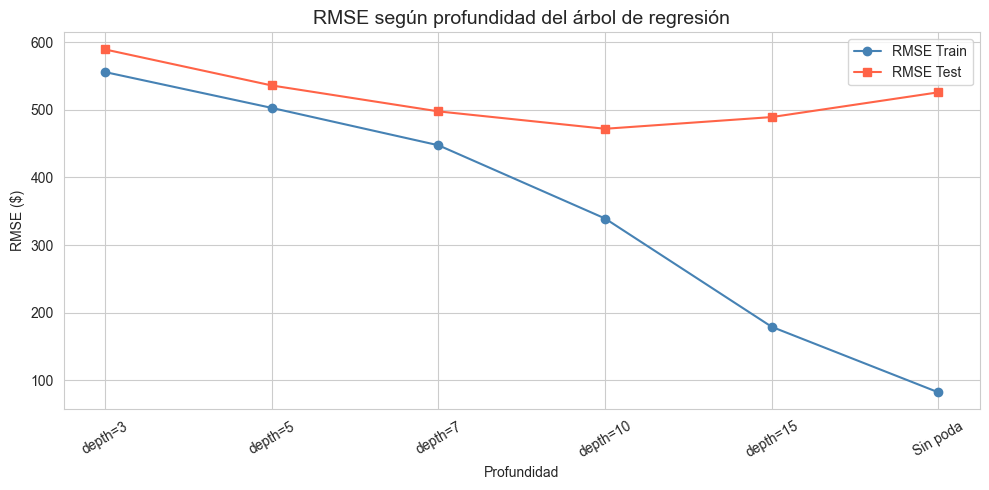


Mejor profundidad para regresión: depth=10
RMSE_train    339.27
RMSE_test     472.12
MAE_test      145.89
R2_train        0.83
R2_test         0.73
Name: depth=10, dtype: float64


In [26]:
# Gráfica RMSE train vs test según profundidad
etiquetas = [str(r['Modelo']) for r in resultados_reg]
rmse_train = df_reg['RMSE_train'].values
rmse_test  = df_reg['RMSE_test'].values

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(etiquetas, rmse_train, marker='o', label='RMSE Train', color='steelblue')
ax.plot(etiquetas, rmse_test,  marker='s', label='RMSE Test',  color='tomato')
ax.set_title('RMSE según profundidad del árbol de regresión', fontsize=14)
ax.set_xlabel('Profundidad')
ax.set_ylabel('RMSE ($)')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

mejor_depth_reg = df_reg['RMSE_test'].idxmin()
print(f'\nMejor profundidad para regresión: {mejor_depth_reg}')
print(df_reg.loc[mejor_depth_reg].round(2))

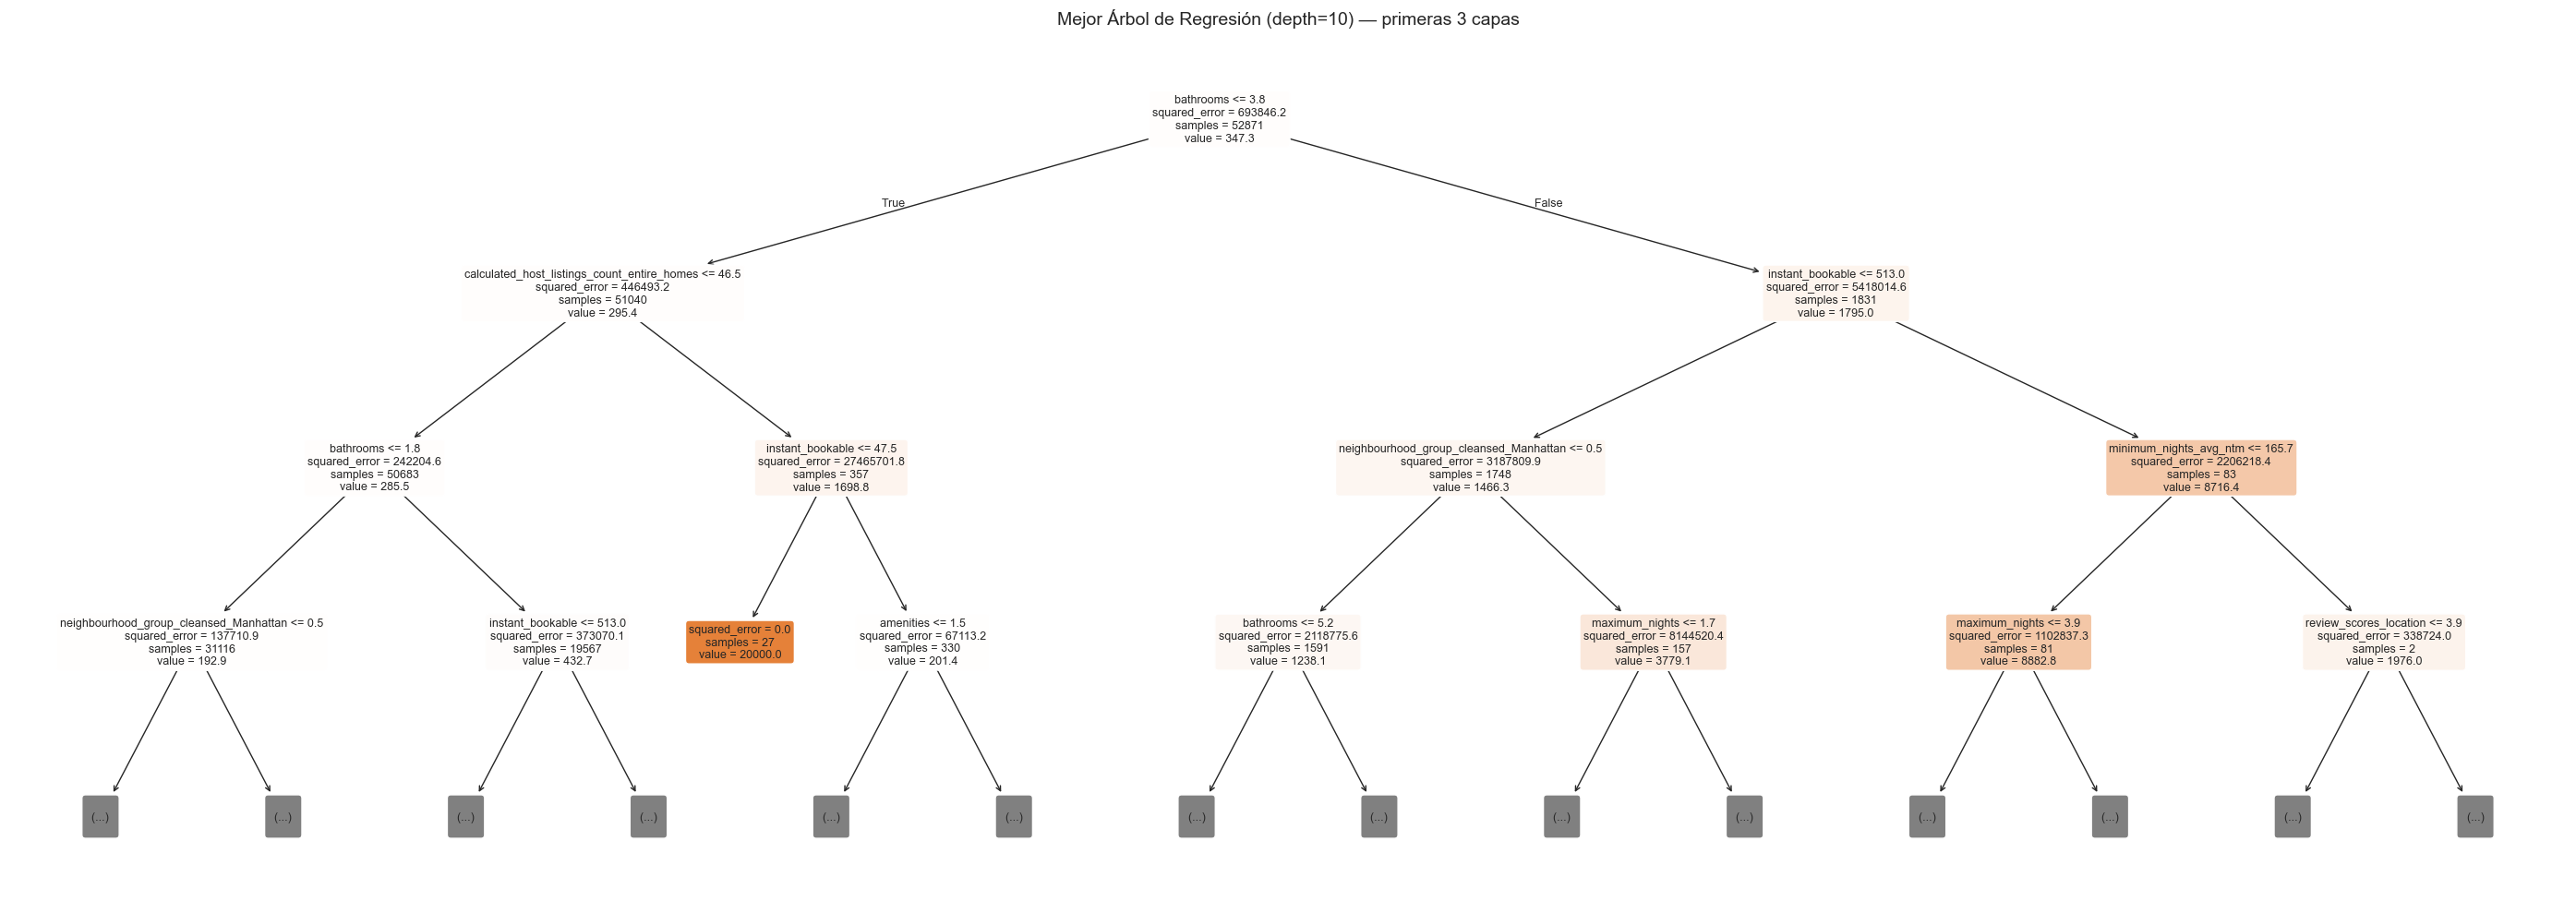

In [27]:
# Extraer la profundidad numérica del índice para reutilizarla
mejor_depth_num = None
for depth in profundidades:
    nombre = f'depth={depth}' if depth else 'Sin poda'
    if nombre == mejor_depth_reg:
        mejor_depth_num = depth
        break

mejor_arbol_reg = DecisionTreeRegressor(max_depth=mejor_depth_num, random_state=123)
mejor_arbol_reg.fit(X_train, y_train)

# Visualización del mejor árbol (primeras 3 capas)
plt.figure(figsize=(28, 10))
plot_tree(mejor_arbol_reg, filled=True, feature_names=list(X.columns),
          max_depth=3, fontsize=9, precision=1, rounded=True)
plt.title(f'Mejor Árbol de Regresión ({mejor_depth_reg}) — primeras 3 capas', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:

# Regresión lineal
lm = LinearRegression()
lm.fit(X_train, y_train)
met_lm = evaluar_regresion(lm, X_train, y_train, X_test, y_test, 'Regresión Lineal')

# Mejor árbol de regresión
met_mejor_arbol = evaluar_regresion(mejor_arbol_reg, X_train, y_train, X_test, y_test,
                                     f'Árbol Regresión ({mejor_depth_reg})')

comparacion = pd.DataFrame([met_lm, met_mejor_arbol]).set_index('Modelo')
print(comparacion.round(2))

                            RMSE_train  RMSE_test  MAE_test  R2_train  R2_test
Modelo                                                                        
Regresión Lineal                749.80     828.34    265.32      0.19     0.16
Árbol Regresión (depth=10)      339.27     472.12    145.89      0.83     0.73


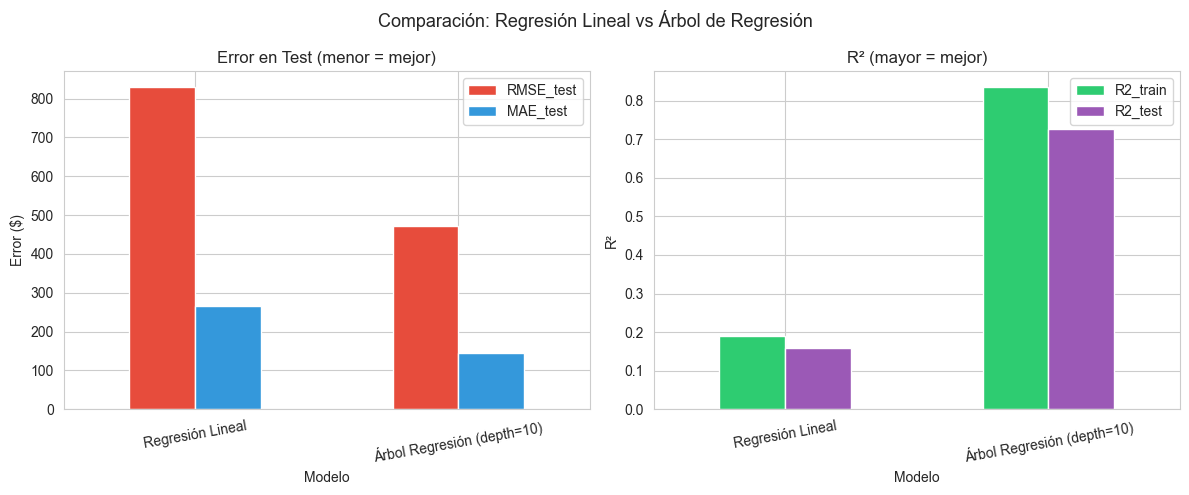

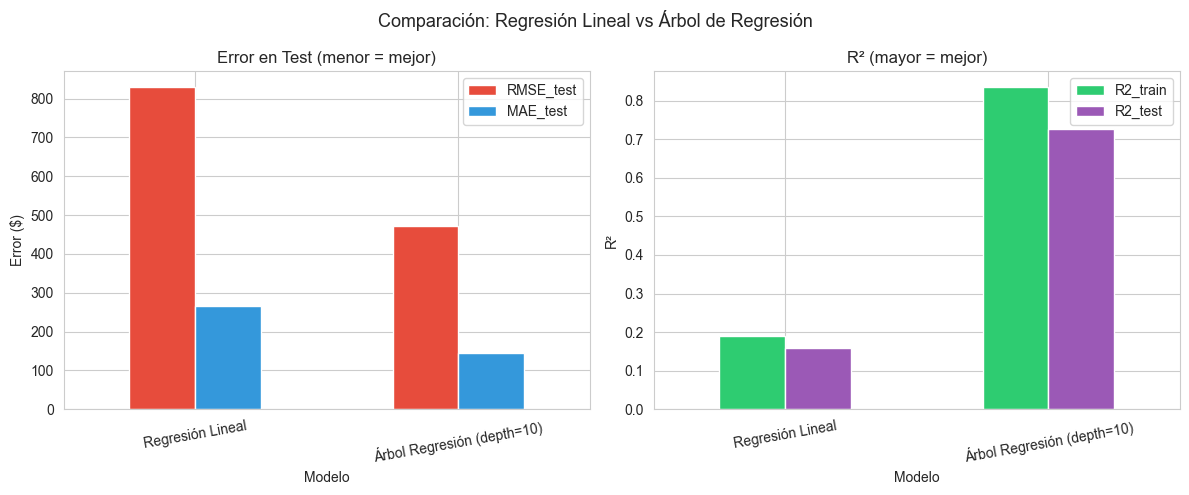

In [29]:
# Gráfica de comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

comparacion[['RMSE_test', 'MAE_test']].plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db'], rot=10)
axes[0].set_title('Error en Test (menor = mejor)')
axes[0].set_ylabel('Error ($)')

comparacion[['R2_train', 'R2_test']].plot(kind='bar', ax=axes[1], color=['#2ecc71','#9b59b6'], rot=10)
axes[1].set_title('R² (mayor = mejor)')
axes[1].set_ylabel('R²')

plt.suptitle('Comparación: Regresión Lineal vs Árbol de Regresión', fontsize=13)
plt.tight_layout()
plt.show()# Gráfica de comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

comparacion[['RMSE_test', 'MAE_test']].plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db'], rot=10)
axes[0].set_title('Error en Test (menor = mejor)')
axes[0].set_ylabel('Error ($)')

comparacion[['R2_train', 'R2_test']].plot(kind='bar', ax=axes[1], color=['#2ecc71','#9b59b6'], rot=10)
axes[1].set_title('R² (mayor = mejor)')
axes[1].set_ylabel('R²')

plt.suptitle('Comparación: Regresión Lineal vs Árbol de Regresión', fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
# Análisis de distribución de precios
stats_precio = df['price'].describe(percentiles=[0.10, 0.25, 0.33, 0.50, 0.66, 0.75, 0.90])
print('Estadísticos del precio por noche:')
print(stats_precio.round(2))

Estadísticos del precio por noche:
count    75531.00
mean       347.94
std        854.85
min          8.00
10%         80.00
25%        119.00
33%        140.00
50%        191.00
66%        260.00
75%        320.00
90%        594.00
max      20000.00
Name: price, dtype: float64


In [31]:
p33 = df['price'].quantile(0.33)
p66 = df['price'].quantile(0.66)

print(f'Límite inferior (p33): ${p33:.2f}')
print(f'Límite superior (p66): ${p66:.2f}')
print(f'\nCategorías:')
print(f'  Económica  → precio ≤ ${p33:.2f}')
print(f'  Intermedia → ${p33:.2f} < precio ≤ ${p66:.2f}')
print(f'  Cara       → precio > ${p66:.2f}')

# Crear la variable categórica
def clasificar_precio(x):
    if x <= p33:
        return 'Economica'
    elif x <= p66:
        return 'Intermedia'
    else:
        return 'Cara'

df['precio_cat'] = df['price'].apply(clasificar_precio)

print('\nDistribución de clases:')
print(df['precio_cat'].value_counts())

Límite inferior (p33): $140.00
Límite superior (p66): $260.00

Categorías:
  Económica  → precio ≤ $140.00
  Intermedia → $140.00 < precio ≤ $260.00
  Cara       → precio > $260.00

Distribución de clases:
precio_cat
Cara          25628
Intermedia    24968
Economica     24935
Name: count, dtype: int64


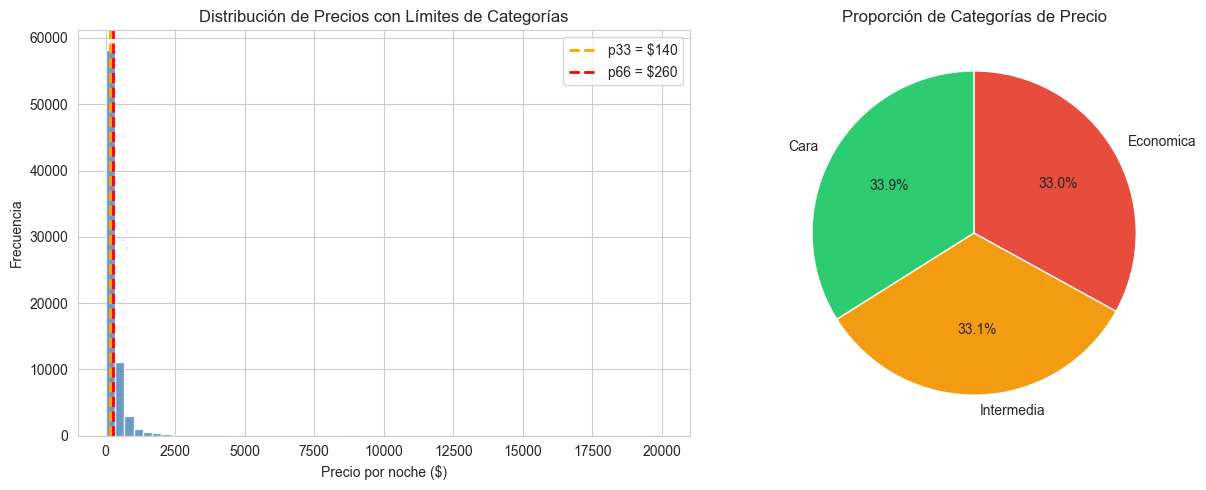

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma con líneas de corte
axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(p33, color='orange', linestyle='--', linewidth=2, label=f'p33 = ${p33:.0f}')
axes[0].axvline(p66, color='red',    linestyle='--', linewidth=2, label=f'p66 = ${p66:.0f}')
axes[0].set_title('Distribución de Precios con Límites de Categorías')
axes[0].set_xlabel('Precio por noche ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Gráfico de pastel
conteo = df['precio_cat'].value_counts()
colores = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%',
            colors=colores, startangle=90)
axes[1].set_title('Proporción de Categorías de Precio')

plt.tight_layout()
plt.show()

In [33]:
# Features: excluir precio Y la variable categórica
X_clas = df.drop(columns=['price', 'precio_cat'])
y_clas = df['precio_cat']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clas, y_clas, test_size=0.3, random_state=123, stratify=y_clas
)

print(f'Train clasificación: {X_train_c.shape[0]} | Test: {X_test_c.shape[0]}')
print('Distribución train:')
print(y_train_c.value_counts())

Train clasificación: 52871 | Test: 22660
Distribución train:
precio_cat
Cara          17939
Intermedia    17478
Economica     17454
Name: count, dtype: int64


In [34]:
# Árbol de clasificación base
clf_base = DecisionTreeClassifier(random_state=123)
clf_base.fit(X_train_c, y_train_c)

print(f'Profundidad: {clf_base.get_depth()} | Hojas: {clf_base.get_n_leaves()}')

Profundidad: 34 | Hojas: 9280


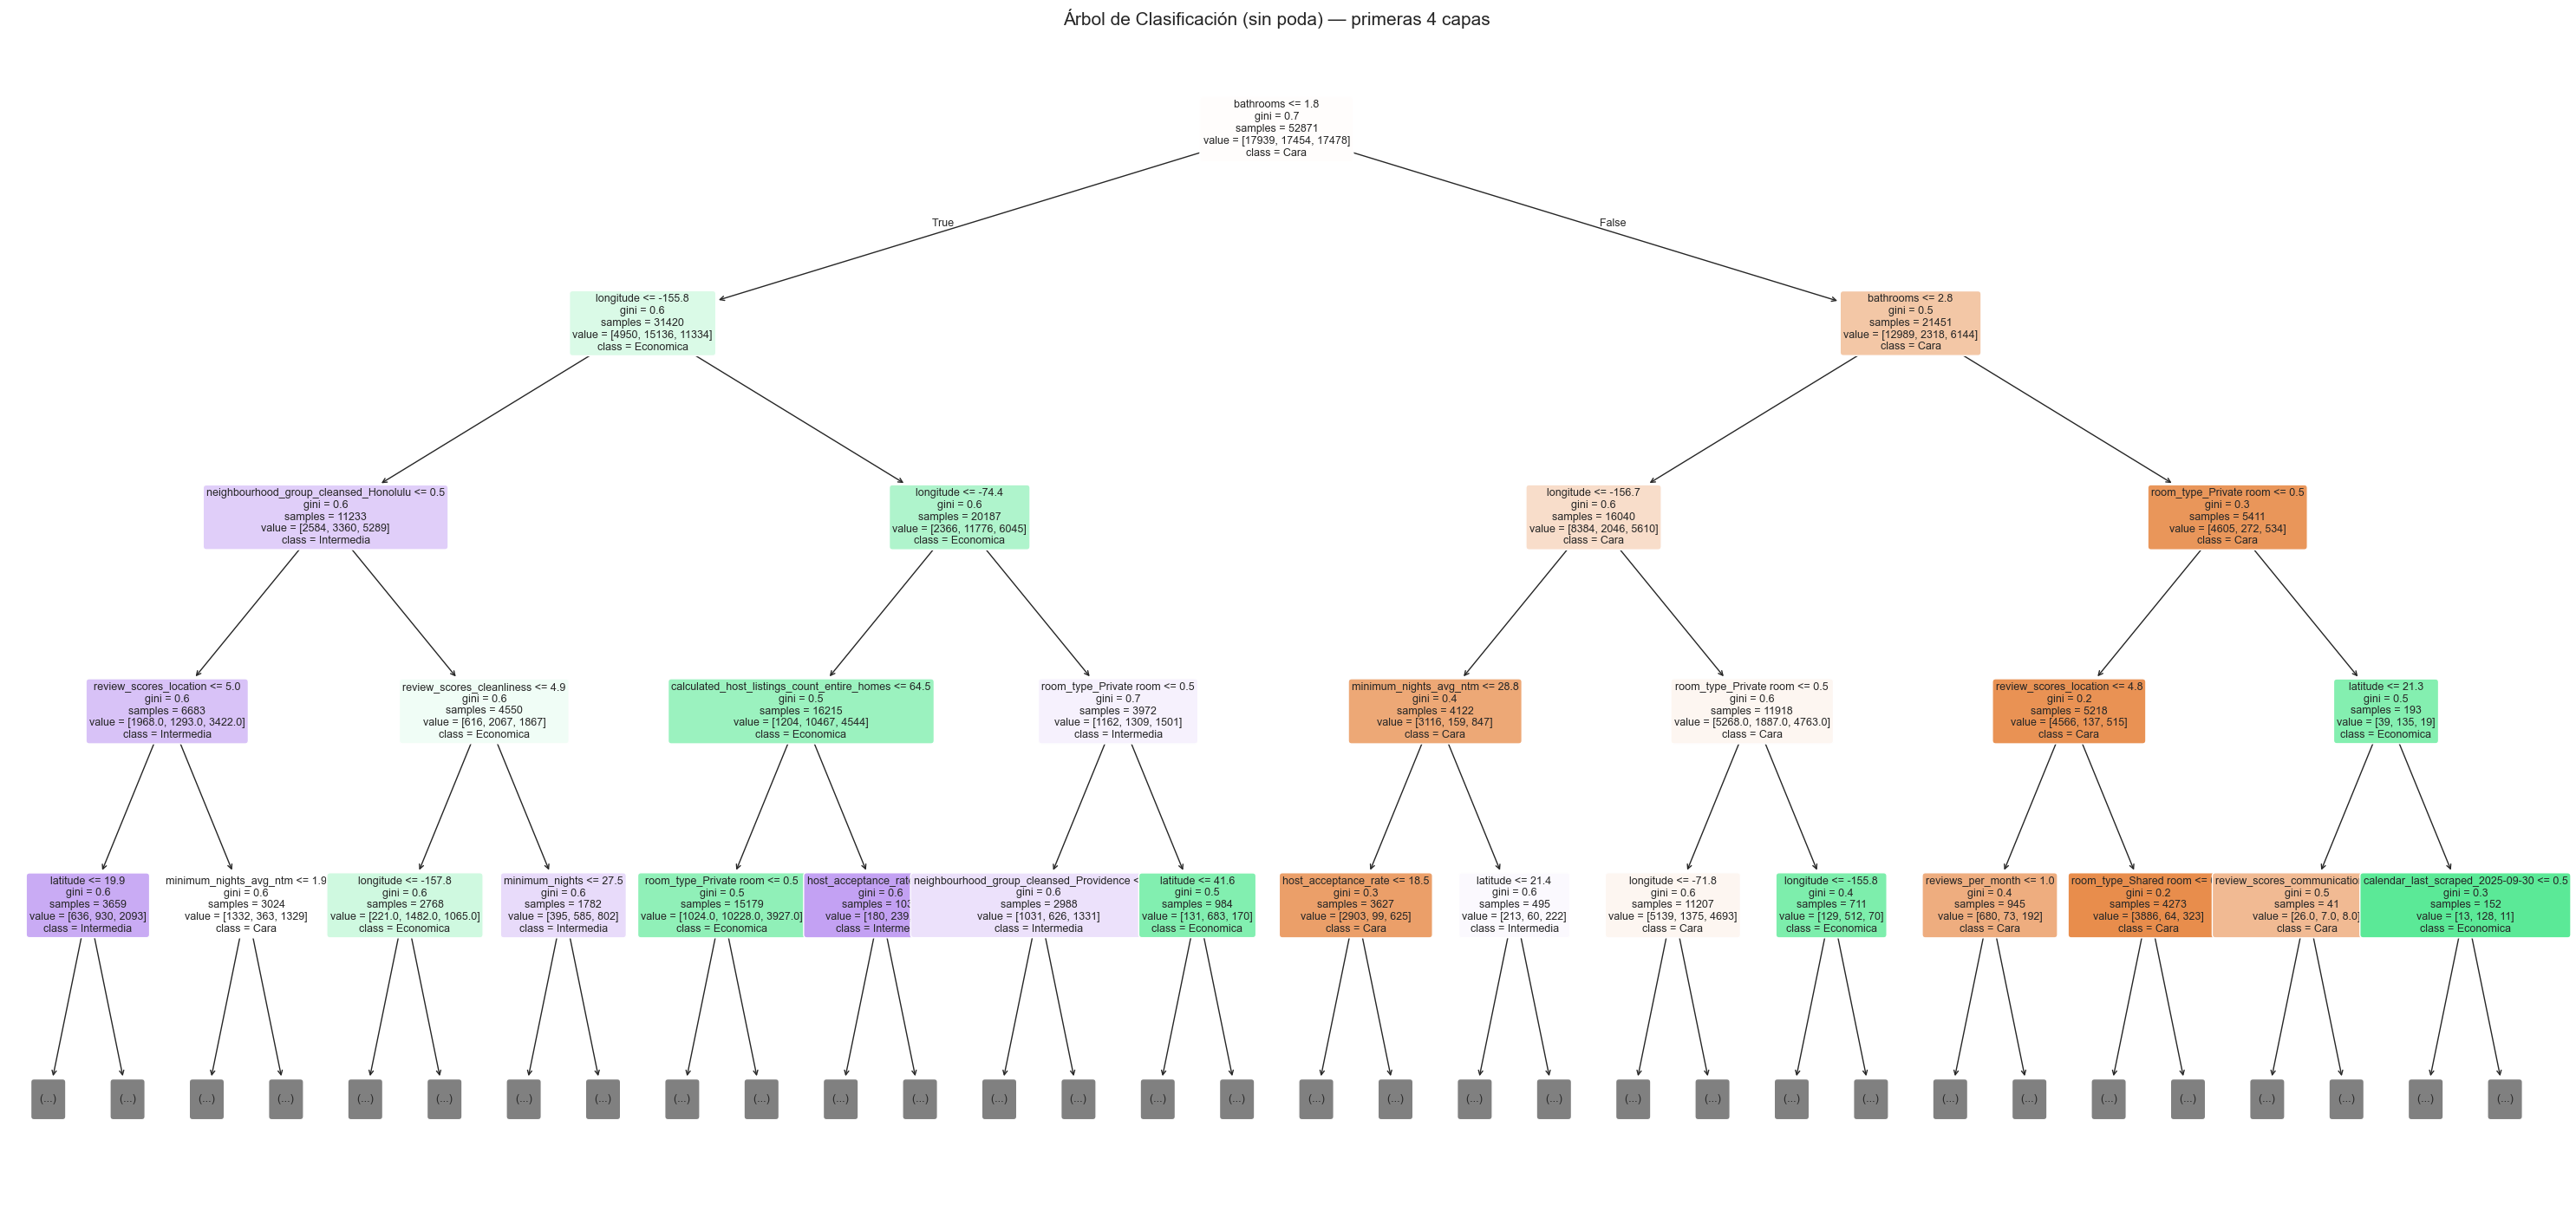

In [35]:
# Visualización gráfica del árbol (primeras 4 capas)
clases = ['Cara', 'Economica', 'Intermedia']

plt.figure(figsize=(30, 14))
plot_tree(
    clf_base,
    filled=True,
    feature_names=list(X_clas.columns),
    class_names=clases,
    max_depth=4,
    fontsize=9,
    rounded=True,
    precision=1
)
plt.title('Árbol de Clasificación (sin poda) — primeras 4 capas', fontsize=15)
plt.tight_layout()
plt.show()

In [36]:
pred_clf_base = clf_base.predict(X_test_c)

acc = accuracy_score(y_test_c, pred_clf_base)
print(f'Accuracy en test: {acc:.4f} ({acc*100:.2f}%)\n')
print('Reporte de clasificación:')
print(classification_report(y_test_c, pred_clf_base, target_names=clases))

Accuracy en test: 0.6720 (67.20%)

Reporte de clasificación:
              precision    recall  f1-score   support

        Cara       0.74      0.73      0.73      7689
   Economica       0.72      0.71      0.72      7481
  Intermedia       0.56      0.57      0.56      7490

    accuracy                           0.67     22660
   macro avg       0.67      0.67      0.67     22660
weighted avg       0.67      0.67      0.67     22660



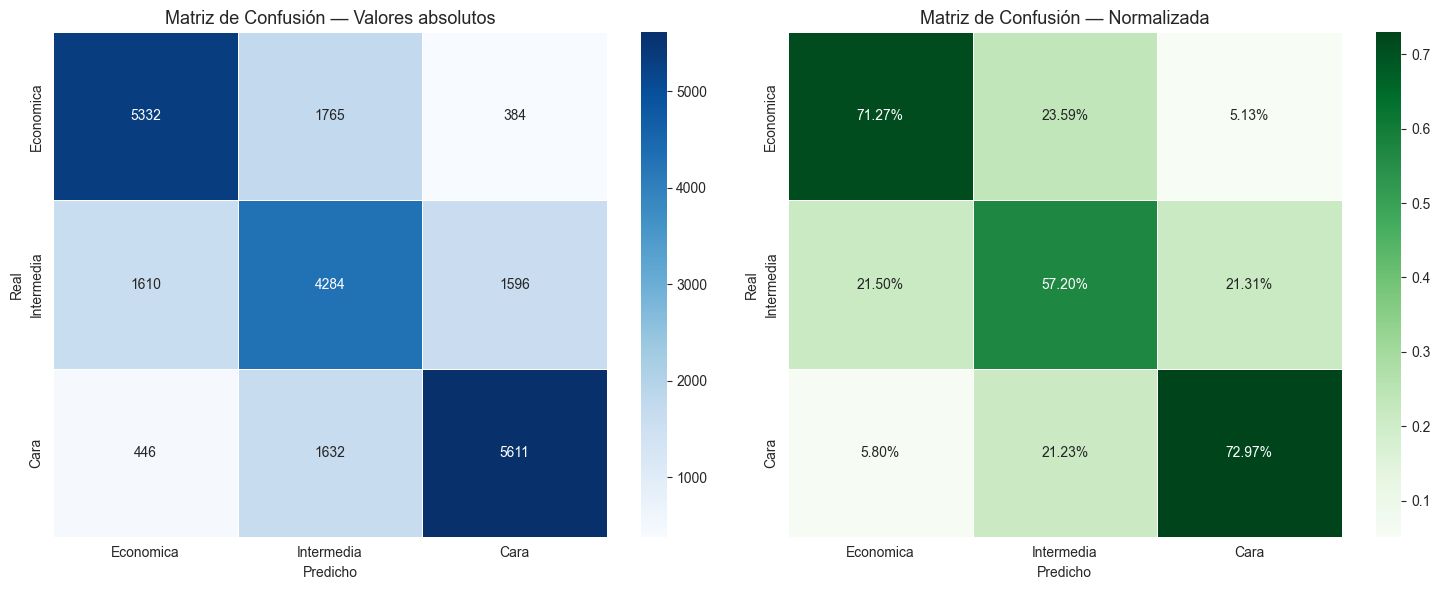

Economica    → Correctos: 5332/7481 (71.3%)
Intermedia   → Correctos: 4284/7490 (57.2%)
Cara         → Correctos: 5611/7689 (73.0%)


In [37]:
orden_clases = ['Economica', 'Intermedia', 'Cara']

cm = confusion_matrix(y_test_c, pred_clf_base, labels=orden_clases)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Matriz de confusión (valores absolutos)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=orden_clases, yticklabels=orden_clases,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matriz de Confusión — Valores absolutos', fontsize=13)
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Matriz de confusión normalizada (porcentajes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=orden_clases, yticklabels=orden_clases,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Matriz de Confusión — Normalizada', fontsize=13)
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Análisis cuantitativo
for i, clase in enumerate(orden_clases):
    correctos = cm[i, i]
    total_real = cm[i, :].sum()
    recall = correctos / total_real if total_real > 0 else 0
    print(f'{clase:12s} → Correctos: {correctos}/{total_real} ({recall:.1%})')

In [38]:
# Validación cruzada estratificada de 10 folds
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

clf_cv = DecisionTreeClassifier(random_state=123)

scores_cv = cross_val_score(clf_cv, X_train_c, y_train_c, cv=cv, scoring='accuracy')

print(f'Accuracy por fold: {np.round(scores_cv, 4)}')
print(f'Media:  {scores_cv.mean():.4f}')
print(f'Std:    {scores_cv.std():.4f}')
print(f'IC 95%: [{scores_cv.mean()-2*scores_cv.std():.4f}, {scores_cv.mean()+2*scores_cv.std():.4f}]')

Accuracy por fold: [0.6689 0.6592 0.6669 0.6614 0.6624 0.6688 0.6705 0.6626 0.6654 0.6594]
Media:  0.6645
Std:    0.0039
IC 95%: [0.6567, 0.6724]


Accuracy árbol base (sin CV):       0.6720
Accuracy árbol con CV (media folds): 0.6645
Accuracy árbol CV sobre test:        0.6720


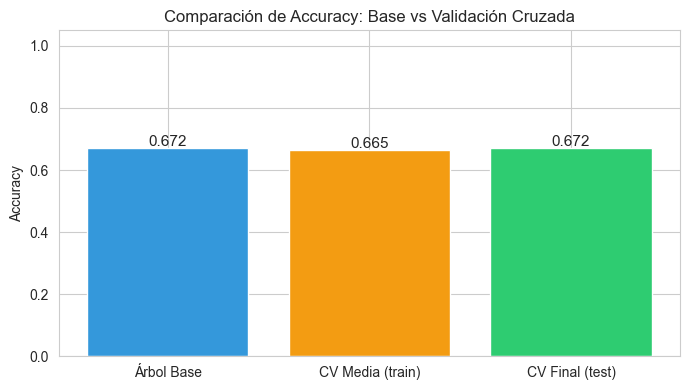

In [39]:
# Entrenar modelo final con todos los datos de train y evaluar en test
clf_cv.fit(X_train_c, y_train_c)
pred_cv = clf_cv.predict(X_test_c)

acc_cv = accuracy_score(y_test_c, pred_cv)
acc_base = accuracy_score(y_test_c, pred_clf_base)

print(f'Accuracy árbol base (sin CV):       {acc_base:.4f}')
print(f'Accuracy árbol con CV (media folds): {scores_cv.mean():.4f}')
print(f'Accuracy árbol CV sobre test:        {acc_cv:.4f}')

# Barras comparativas
fig, ax = plt.subplots(figsize=(7, 4))
modelos_cv = ['Árbol Base', 'CV Media (train)', 'CV Final (test)']
valores_cv = [acc_base, scores_cv.mean(), acc_cv]
colores_cv = ['#3498db', '#f39c12', '#2ecc71']
bars = ax.bar(modelos_cv, valores_cv, color=colores_cv, edgecolor='white')
for bar, val in zip(bars, valores_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Comparación de Accuracy: Base vs Validación Cruzada')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.show()

In [40]:
profundidades_clas = [3, 5, 7, 10, 15, None]
resultados_clas = []

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

for depth in profundidades_clas:
    m = DecisionTreeClassifier(max_depth=depth, random_state=123)
    m.fit(X_train_c, y_train_c)

    # CV score
    cv_sc = cross_val_score(m, X_train_c, y_train_c, cv=cv_strat, scoring='accuracy')

    # Test score
    pred_d = m.predict(X_test_c)
    acc_test = accuracy_score(y_test_c, pred_d)

    nombre = f'depth={depth}' if depth else 'Sin poda'
    resultados_clas.append({
        'Modelo': nombre,
        'Acc_train': accuracy_score(y_train_c, m.predict(X_train_c)),
        'Acc_CV_media': cv_sc.mean(),
        'Acc_CV_std': cv_sc.std(),
        'Acc_test': acc_test
    })

df_clas_res = pd.DataFrame(resultados_clas).set_index('Modelo')
print(df_clas_res.round(4))

          Acc_train  Acc_CV_media  Acc_CV_std  Acc_test
Modelo                                                 
depth=3      0.5777        0.5763      0.0058    0.5748
depth=5      0.6323        0.6262      0.0039    0.6306
depth=7      0.6593        0.6500      0.0010    0.6500
depth=10     0.7187        0.6778      0.0029    0.6825
depth=15     0.8544        0.6837      0.0046    0.6925
Sin poda     0.9998        0.6593      0.0029    0.6720


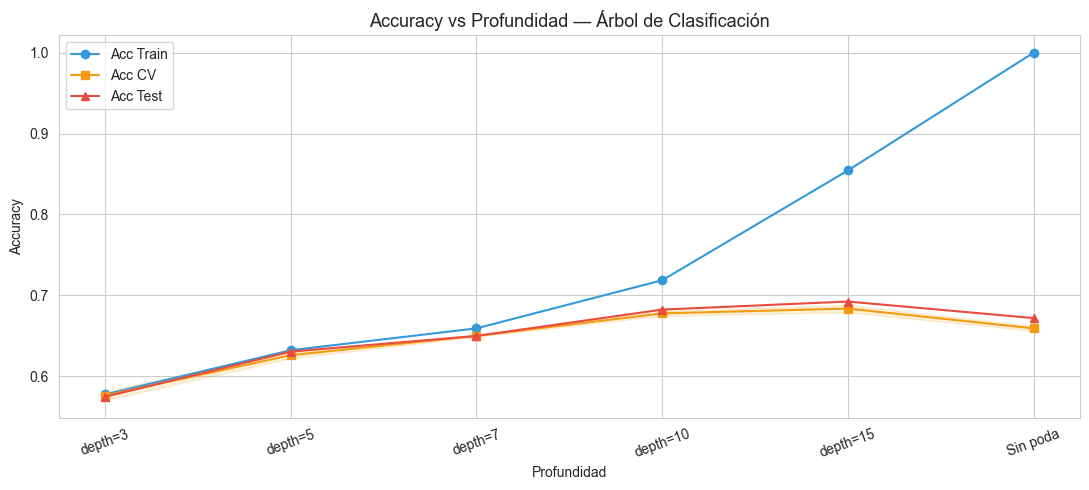


Mejor profundidad para clasificación: depth=15
Acc_train       0.8544
Acc_CV_media    0.6837
Acc_CV_std      0.0046
Acc_test        0.6925
Name: depth=15, dtype: float64


In [41]:
fig, ax = plt.subplots(figsize=(11, 5))
etiq = df_clas_res.index.tolist()
ax.plot(etiq, df_clas_res['Acc_train'],    marker='o', label='Acc Train',   color='#3498db')
ax.plot(etiq, df_clas_res['Acc_CV_media'], marker='s', label='Acc CV',      color='#f39c12')
ax.plot(etiq, df_clas_res['Acc_test'],     marker='^', label='Acc Test',    color='#e74c3c')
ax.fill_between(
    etiq,
    df_clas_res['Acc_CV_media'] - df_clas_res['Acc_CV_std'],
    df_clas_res['Acc_CV_media'] + df_clas_res['Acc_CV_std'],
    alpha=0.15, color='#f39c12'
)
ax.set_title('Accuracy vs Profundidad — Árbol de Clasificación', fontsize=13)
ax.set_xlabel('Profundidad')
ax.set_ylabel('Accuracy')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

mejor_prof_clas = df_clas_res['Acc_test'].idxmax()
print(f'\nMejor profundidad para clasificación: {mejor_prof_clas}')
print(df_clas_res.loc[mejor_prof_clas].round(4))

In [42]:
# Reentrenar el mejor clasificador y mostrar sus métricas completas
mejor_depth_clas_num = None
for depth in profundidades_clas:
    nombre = f'depth={depth}' if depth else 'Sin poda'
    if nombre == mejor_prof_clas:
        mejor_depth_clas_num = depth
        break

mejor_clf = DecisionTreeClassifier(max_depth=mejor_depth_clas_num, random_state=123)
mejor_clf.fit(X_train_c, y_train_c)
pred_mejor_clf = mejor_clf.predict(X_test_c)

print(f'Mejor árbol clasificación: {mejor_prof_clas}')
print(classification_report(y_test_c, pred_mejor_clf, target_names=clases))

Mejor árbol clasificación: depth=15
              precision    recall  f1-score   support

        Cara       0.76      0.73      0.75      7689
   Economica       0.75      0.74      0.74      7481
  Intermedia       0.58      0.60      0.59      7490

    accuracy                           0.69     22660
   macro avg       0.69      0.69      0.69     22660
weighted avg       0.70      0.69      0.69     22660



In [43]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=123, n_jobs=-1)
rf_reg.fit(X_train, y_train)

met_rf_reg = evaluar_regresion(rf_reg, X_train, y_train, X_test, y_test, 'Random Forest Regresión')

# Tabla comparativa final de regresión
tabla_final_reg = pd.DataFrame([met_lm, met_mejor_arbol, met_rf_reg]).set_index('Modelo')
print('Comparación final — Modelos de Regresión:')
print(tabla_final_reg.round(2))

Comparación final — Modelos de Regresión:
                            RMSE_train  RMSE_test  MAE_test  R2_train  R2_test
Modelo                                                                        
Regresión Lineal                749.80     828.34    265.32      0.19     0.16
Árbol Regresión (depth=10)      339.27     472.12    145.89      0.83     0.73
Random Forest Regresión         172.54     407.60    116.23      0.96     0.80


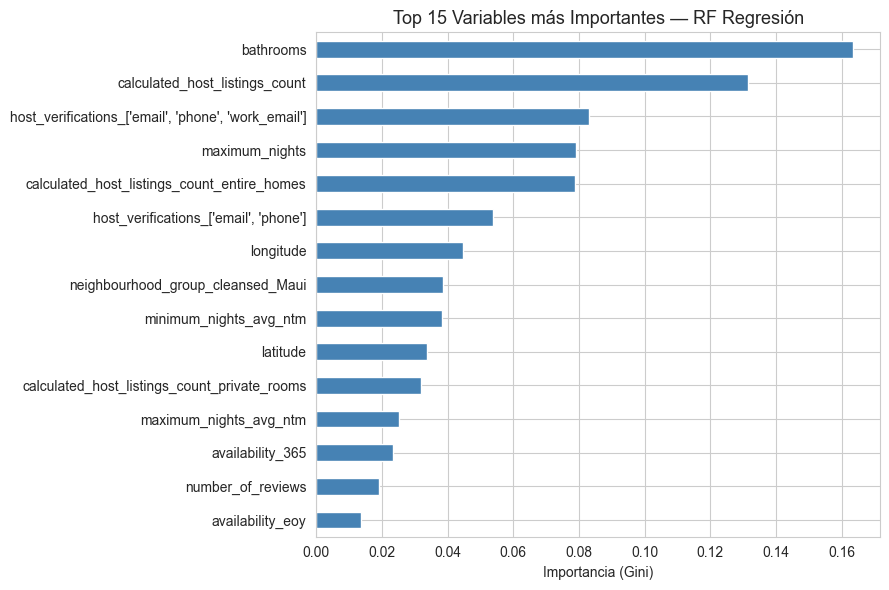

In [44]:
# Importancia de variables — Random Forest Regresión
importancias_reg = pd.Series(
    rf_reg.feature_importances_,
    index=X_train.columns
)
top15_reg = importancias_reg.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top15_reg.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 15 Variables más Importantes — RF Regresión', fontsize=13)
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

In [45]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=123, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)

pred_rf_clf = rf_clf.predict(X_test_c)

acc_rf = accuracy_score(y_test_c, pred_rf_clf)
print(f'Accuracy Random Forest (clasificación): {acc_rf:.4f}')
print()
print(classification_report(y_test_c, pred_rf_clf, target_names=clases))

Accuracy Random Forest (clasificación): 0.7481

              precision    recall  f1-score   support

        Cara       0.81      0.81      0.81      7689
   Economica       0.77      0.82      0.80      7481
  Intermedia       0.66      0.61      0.63      7490

    accuracy                           0.75     22660
   macro avg       0.75      0.75      0.75     22660
weighted avg       0.75      0.75      0.75     22660



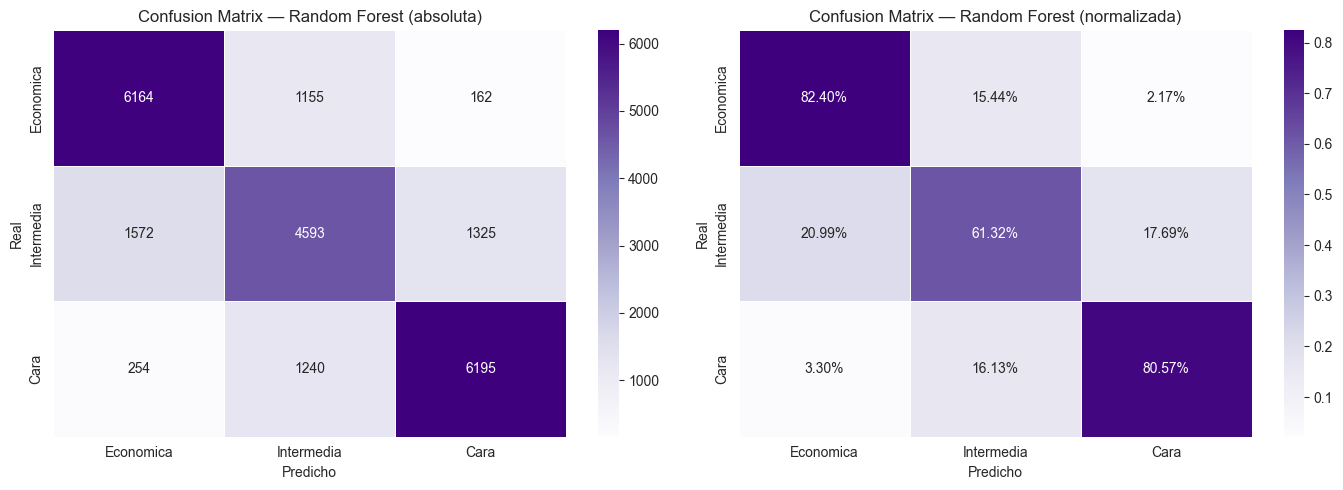

In [46]:
# Matriz de confusión — Random Forest
cm_rf = confusion_matrix(y_test_c, pred_rf_clf, labels=orden_clases)
cm_rf_norm = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=orden_clases, yticklabels=orden_clases,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — Random Forest (absoluta)')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

sns.heatmap(cm_rf_norm, annot=True, fmt='.2%', cmap='Purples',
            xticklabels=orden_clases, yticklabels=orden_clases,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Random Forest (normalizada)')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

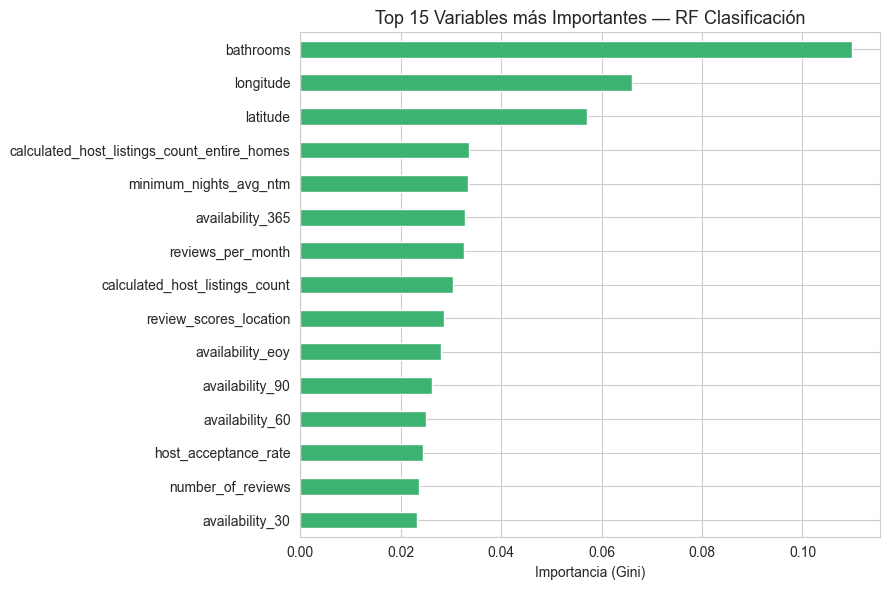

In [47]:
# Importancia de variables — RF Clasificación
importancias_clf = pd.Series(rf_clf.feature_importances_, index=X_clas.columns)
top15_clf = importancias_clf.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top15_clf.plot(kind='barh', color='mediumseagreen', ax=ax)
ax.set_title('Top 15 Variables más Importantes — RF Clasificación', fontsize=13)
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

In [48]:
# Tabla comparativa clasificación
tabla_clas = pd.DataFrame([
    {'Modelo': 'Árbol base (sin poda)',        'Accuracy_test': acc_base},
    {'Modelo': f'Mejor árbol ({mejor_prof_clas})', 'Accuracy_test': accuracy_score(y_test_c, pred_mejor_clf)},
    {'Modelo': 'Random Forest (100 árboles)',  'Accuracy_test': acc_rf},
]).set_index('Modelo')

print('Comparación final — Modelos de Clasificación:')
print(tabla_clas.round(4))

Comparación final — Modelos de Clasificación:
                             Accuracy_test
Modelo                                    
Árbol base (sin poda)               0.6720
Mejor árbol (depth=15)              0.6925
Random Forest (100 árboles)         0.7481


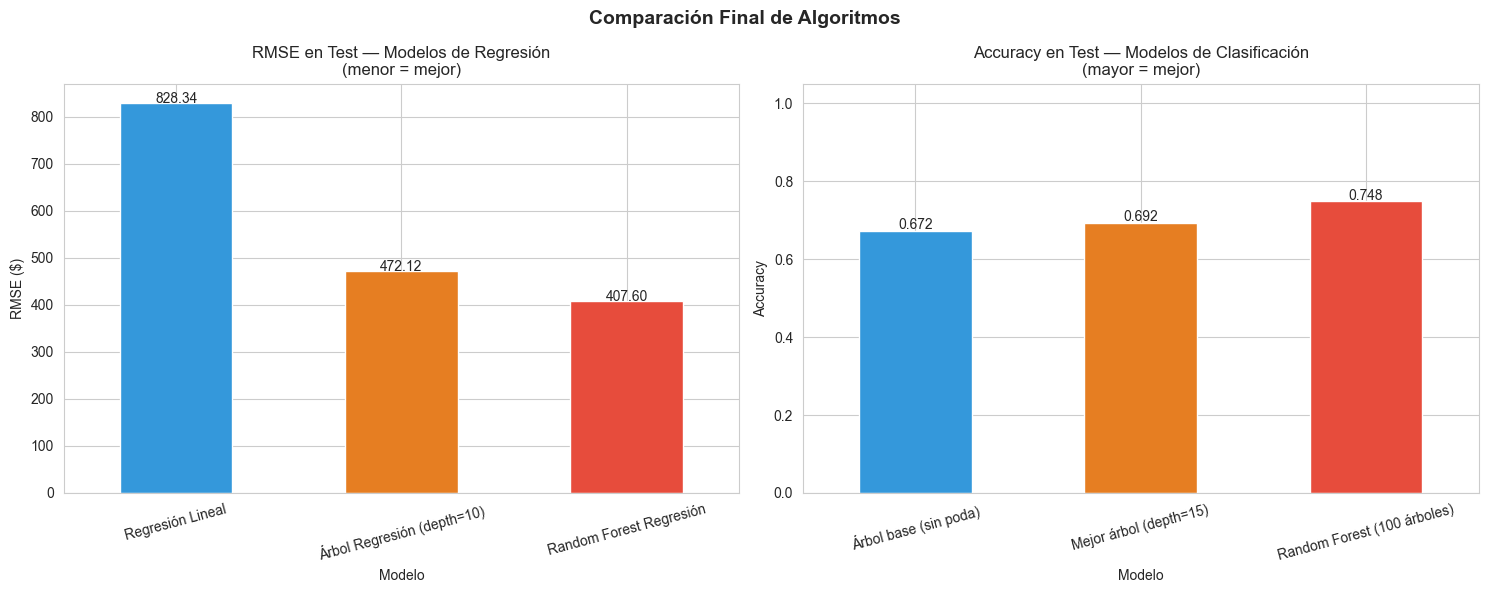

In [49]:
# Gráfica comparativa final (regresión y clasificación)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Regresión: RMSE test
tabla_final_reg['RMSE_test'].plot(
    kind='bar', ax=axes[0],
    color=['#3498db', '#e67e22', '#e74c3c'],
    edgecolor='white', rot=15
)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.2f}',
                 ha='center', fontsize=10)
axes[0].set_title('RMSE en Test — Modelos de Regresión\n(menor = mejor)', fontsize=12)
axes[0].set_ylabel('RMSE ($)')

# Clasificación: Accuracy test
tabla_clas['Accuracy_test'].plot(
    kind='bar', ax=axes[1],
    color=['#3498db', '#e67e22', '#e74c3c'],
    edgecolor='white', rot=15
)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}',
                 ha='center', fontsize=10)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Accuracy en Test — Modelos de Clasificación\n(mayor = mejor)', fontsize=12)
axes[1].set_ylabel('Accuracy')

plt.suptitle('Comparación Final de Algoritmos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()